<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/Naive_bayes_shivam_cs23186_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform an analysis of the Breast Cancer dataset using the Gaussian Naive Bayes model. This involves loading the dataset, conducting basic data analysis, splitting the data into 70/30 and 80/20 train/test ratios, training the model on both splits, evaluating performance using accuracy, confusion matrix, and classification report, comparing results with visualizations, and drawing a conclusion on the optimal split ratio. Finally, provide the complete Google Colab Python code.

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Breast Cancer dataset
cancer = load_breast_cancer()

print("Libraries imported and Breast Cancer dataset loaded successfully.")

Libraries imported and Breast Cancer dataset loaded successfully.


## Convert to DataFrame and Basic Data Analysis



In [ ]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Shape of the DataFrame:")
print(df.shape)
print("\n")

print("DataFrame Info:")
df.info()
print("\n")

print("Descriptive Statistics:")
print(df.describe())
print("\n")

print("Missing Values:")
print(df.isnull().sum())
print("\n")

print("Target Variable Class Distribution:")
print(df['target'].value_counts())


Shape of the DataFrame:
(569, 31)


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569

## Split Dataset for Training and Testing


Split the dataset into features (X) and target (y). Apply train-test split with two different ratios: 70% training / 30% testing and 80% training / 20% testing.


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

# Split 1: 70% training / 30% testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

# Split 2: 80% training / 20% testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into features (X) and target (y).")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}\n")

print("70/30 Split Shapes:")
print(f"X_train_70: {X_train_70.shape}, X_test_70: {X_test_70.shape}")
print(f"y_train_70: {y_train_70.shape}, y_test_70: {y_test_70.shape}\n")

print("80/20 Split Shapes:")
print(f"X_train_80: {X_train_80.shape}, X_test_80: {X_test_80.shape}")
print(f"y_train_80: {y_train_80.shape}, y_test_80: {y_test_80.shape}")

Dataset split into features (X) and target (y).
Shape of X: (569, 30), Shape of y: (569,)

70/30 Split Shapes:
X_train_70: (398, 30), X_test_70: (171, 30)
y_train_70: (398,), y_test_70: (171,)

80/20 Split Shapes:
X_train_80: (455, 30), X_test_80: (114, 30)
y_train_80: (455,), y_test_80: (114,)


In [ ]:
model_70 = GaussianNB()
model_80 = GaussianNB()

# Train model on 70/30 split
model_70.fit(X_train_70, y_train_70)
print("Gaussian Naive Bayes model trained on 70/30 split.")

# Train model on 80/20 split
model_80.fit(X_train_80, y_train_80)
print("Gaussian Naive Bayes model trained on 80/20 split.")

Gaussian Naive Bayes model trained on 70/30 split.
Gaussian Naive Bayes model trained on 80/20 split.


## Model Evaluation
.



In [ ]:
print("Evaluation for 70/30 Split:")
# Make predictions
y_pred_70 = model_70.predict(X_test_70)

# Calculate accuracy
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
print(f"Accuracy: {accuracy_70:.4f}")

# Generate confusion matrix
conf_matrix_70 = confusion_matrix(y_test_70, y_pred_70)
print("Confusion Matrix:")
print(conf_matrix_70)

# Generate classification report
class_report_70 = classification_report(y_test_70, y_pred_70)
print("Classification Report:")
print(class_report_70)

print("\n" + "-"*30 + "\n")

print("Evaluation for 80/20 Split:")
# Make predictions
y_pred_80 = model_80.predict(X_test_80)

# Calculate accuracy
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
print(f"Accuracy: {accuracy_80:.4f}")

# Generate confusion matrix
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)
print("Confusion Matrix:")
print(conf_matrix_80)

# Generate classification report
class_report_80 = classification_report(y_test_80, y_pred_80)
print("Classification Report:")
print(class_report_80)

Evaluation for 70/30 Split:
Accuracy: 0.9415
Confusion Matrix:
[[ 57   6]
 [  4 104]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


------------------------------

Evaluation for 80/20 Split:
Accuracy: 0.9737
Confusion Matrix:
[[40  3]
 [ 0 71]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Compare Results with Visualizations

Visualize the comparison of performance metrics (accuracy and confusion matrices) between the 70/30 and 80/20 splits. This will help in understanding which split ratio yielded better results.

Visualizing comparison of model performance...


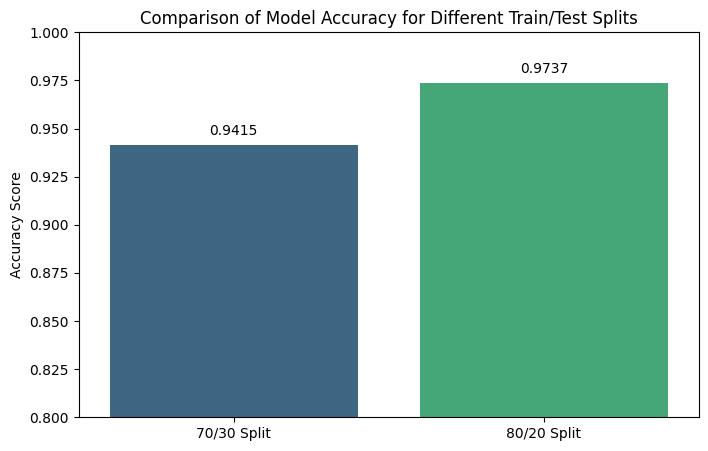

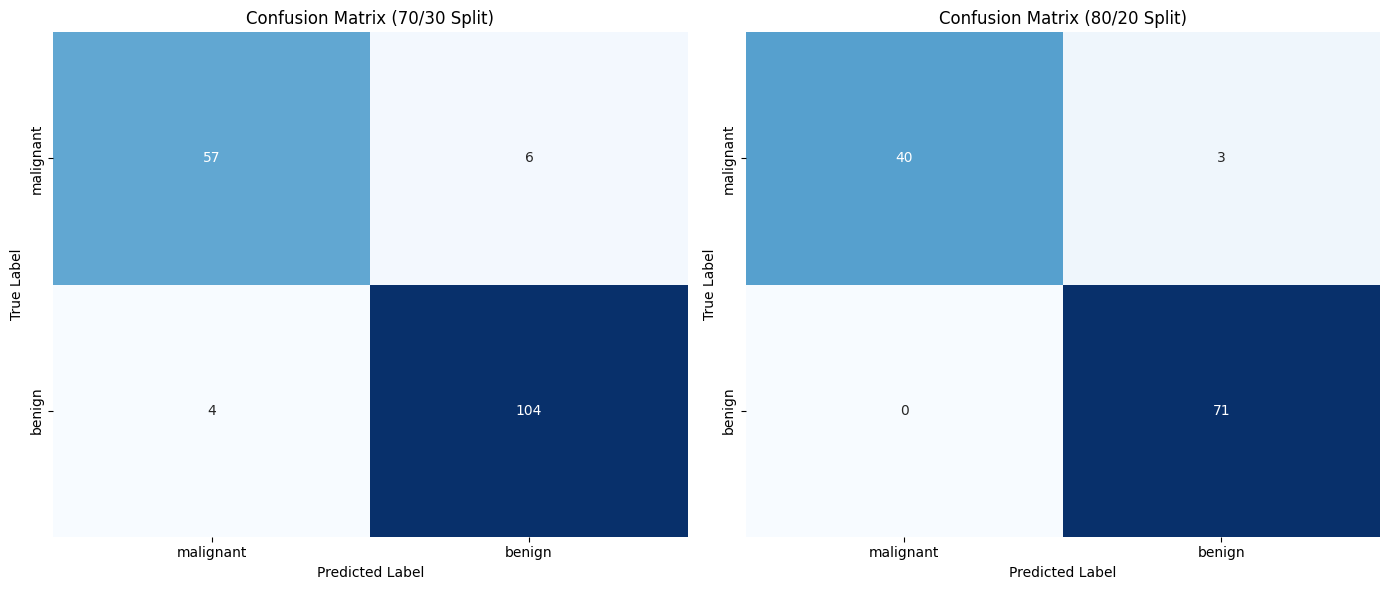

Accuracy and Confusion Matrix plots generated for comparison.


In [ ]:
print("Visualizing comparison of model performance...")

# 1. Compare Accuracy Scores
accuracy_scores = [accuracy_70, accuracy_80]
split_ratios = ['70/30 Split', '80/20 Split']

plt.figure(figsize=(8, 5))
sns.barplot(x=split_ratios, y=accuracy_scores, hue=split_ratios, palette='viridis', legend=False)
plt.title('Comparison of Model Accuracy for Different Train/Test Splits')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0) # Set y-axis limit for better comparison
for index, value in enumerate(accuracy_scores):
    plt.text(index, value + 0.005, f'{value:.4f}', ha='center')
plt.show()

# 2. Compare Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix_70, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (70/30 Split)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(conf_matrix_80, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (80/20 Split)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Accuracy and Confusion Matrix plots generated for comparison.")

Libraries imported and Breast Cancer dataset loaded successfully.
Shape of the DataFrame:
(569, 31)


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error 

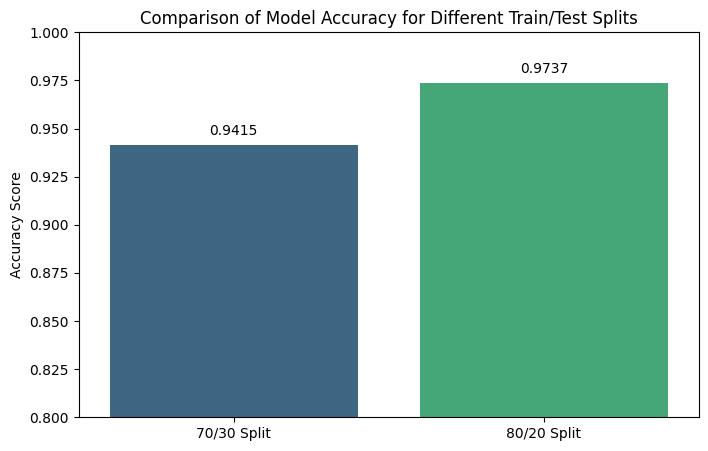

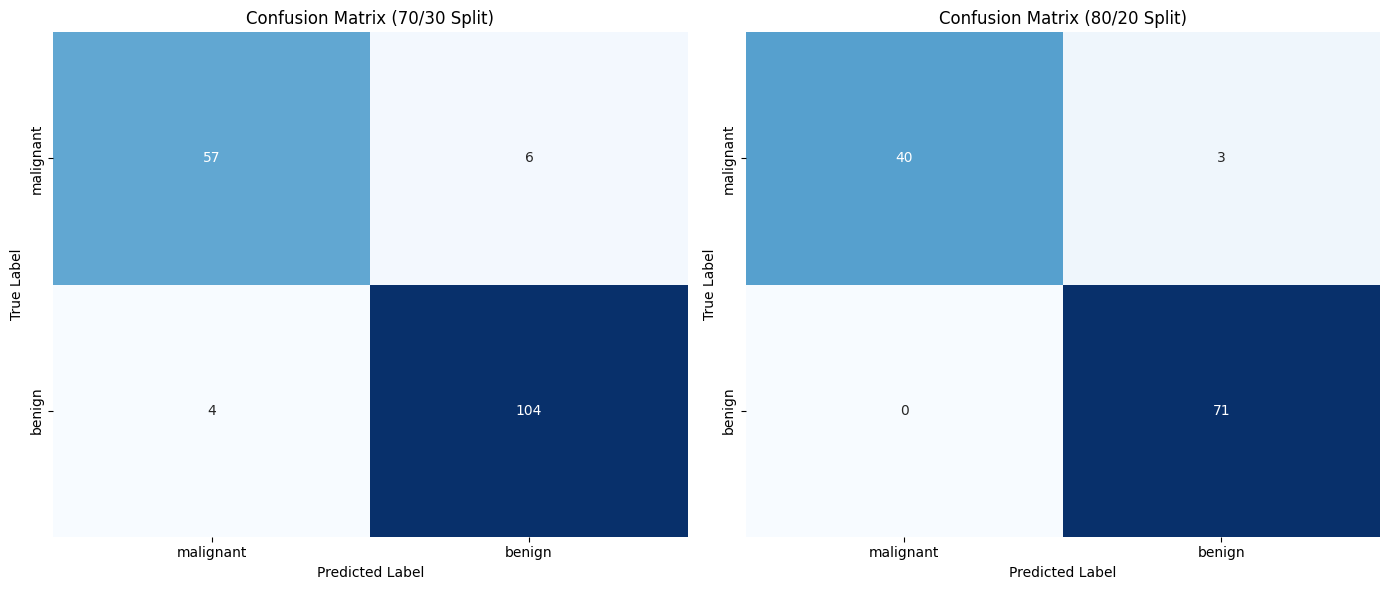

Accuracy and Confusion Matrix plots generated for comparison.


In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Breast Cancer dataset
cancer = load_breast_cancer()

print("Libraries imported and Breast Cancer dataset loaded successfully.")

# Convert to DataFrame and Basic Data Analysis
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Shape of the DataFrame:")
print(df.shape)
print("\n")

print("DataFrame Info:")
df.info()
print("\n")

print("Descriptive Statistics:")
print(df.describe())
print("\n")

print("Missing Values:")
print(df.isnull().sum())
print("\n")

print("Target Variable Class Distribution:")
print(df['target'].value_counts())

# Split Dataset for Training and Testing
X = df.drop('target', axis=1)
y = df['target']

# Split 1: 70% training / 30% testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

# Split 2: 80% training / 20% testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDataset split into features (X) and target (y).")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}\n")

print("70/30 Split Shapes:")
print(f"X_train_70: {X_train_70.shape}, X_test_70: {X_test_70.shape}")
print(f"y_train_70: {y_train_70.shape}, y_test_70: {y_test_70.shape}\n")

print("80/20 Split Shapes:")
print(f"X_train_80: {X_train_80.shape}, X_test_80: {X_test_80.shape}")
print(f"y_train_80: {y_train_80.shape}, y_test_80: {y_test_80.shape}")

# Train Gaussian Naive Bayes Model
model_70 = GaussianNB()
model_80 = GaussianNB()

# Train model on 70/30 split
model_70.fit(X_train_70, y_train_70)
print("\nGaussian Naive Bayes model trained on 70/30 split.")

# Train model on 80/20 split
model_80.fit(X_train_80, y_train_80)
print("Gaussian Naive Bayes model trained on 80/20 split.")

# Model Evaluation
print("\nEvaluation for 70/30 Split:")
# Make predictions
y_pred_70 = model_70.predict(X_test_70)

# Calculate accuracy
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
print(f"Accuracy: {accuracy_70:.4f}")

# Generate confusion matrix
conf_matrix_70 = confusion_matrix(y_test_70, y_pred_70)
print("Confusion Matrix:")
print(conf_matrix_70)

# Generate classification report
class_report_70 = classification_report(y_test_70, y_pred_70)
print("Classification Report:")
print(class_report_70)

print("\n" + "-"*30 + "\n")

print("Evaluation for 80/20 Split:")
# Make predictions
y_pred_80 = model_80.predict(X_test_80)

# Calculate accuracy
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
print(f"Accuracy: {accuracy_80:.4f}")

# Generate confusion matrix
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)
print("Confusion Matrix:")
print(conf_matrix_80)

# Generate classification report
class_report_80 = classification_report(y_test_80, y_pred_80)
print("Classification Report:")
print(class_report_80)

# Compare Results with Visualizations
print("\nVisualizing comparison of model performance...")

# 1. Compare Accuracy Scores
accuracy_scores = [accuracy_70, accuracy_80]
split_ratios = ['70/30 Split', '80/20 Split']

plt.figure(figsize=(8, 5))
sns.barplot(x=split_ratios, y=accuracy_scores, hue=split_ratios, palette='viridis', legend=False)
plt.title('Comparison of Model Accuracy for Different Train/Test Splits')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0) # Set y-axis limit for better comparison
for index, value in enumerate(accuracy_scores):
    plt.text(index, value + 0.005, f'{value:.4f}', ha='center')
plt.show()

# 2. Compare Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix_70, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (70/30 Split)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(conf_matrix_80, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (80/20 Split)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Accuracy and Confusion Matrix plots generated for comparison.")



--- Performance Metrics Summary ---


,Metric,70/30 Split,80/20 Split
0,Accuracy,0.94152,0.973684
1,Precision (Class 0),0.93000,1.000000
2,Recall (Class 0),0.90000,0.930000
3,F1-Score (Class 0),0.92000,0.960000
4,Precision (Class 1),0.95000,0.960000
5,Recall (Class 1),0.96000,1.000000
6,F1-Score (Class 1),0.95000,0.980000
7,Macro Avg Precision,0.94000,0.980000
8,Macro Avg Recall,0.93000,0.970000
9,Macro Avg F1-Score,0.94000,0.970000


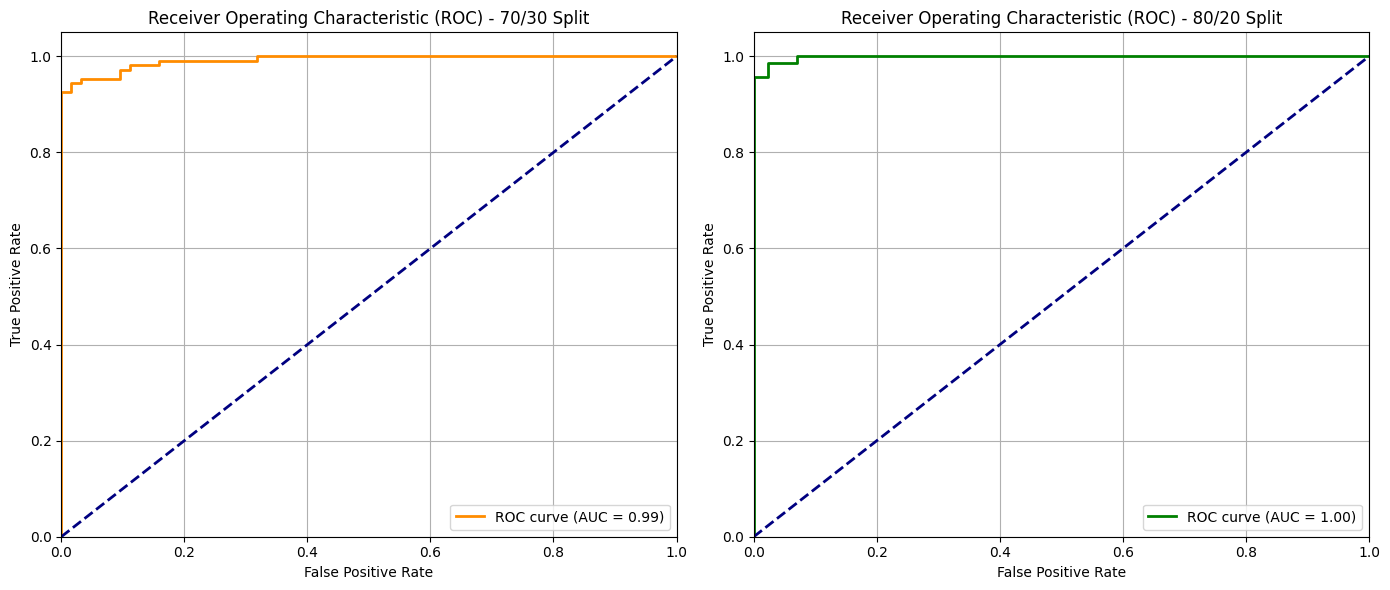

Performance metrics table and ROC curves generated.


In [4]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB # Import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# Re-load the dataset and perform split (to ensure all variables are defined)
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
X = df.drop('target', axis=1)
y = df['target']

# Split 1: 70% training / 30% testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

# Split 2: 80% training / 20% testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)


# Re-initialize and train models
model_70 = GaussianNB()
model_80 = GaussianNB()

# Train model on 70/30 split
model_70.fit(X_train_70, y_train_70)

# Train model on 80/20 split
model_80.fit(X_train_80, y_train_80)

# --- Re-evaluate models to ensure classification reports are available ---
# Make predictions for 70/30 split
y_pred_70 = model_70.predict(X_test_70)
# Calculate accuracy for 70/30 split
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
# Generate classification report for 70/30 split
class_report_70 = classification_report(y_test_70, y_pred_70)

# Make predictions for 80/20 split
y_pred_80 = model_80.predict(X_test_80)
# Calculate accuracy for 80/20 split
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
# Generate classification report for 80/20 split
class_report_80 = classification_report(y_test_80, y_pred_80)


# --- Create a summary table of metrics ---
# Parse classification report for 70/30 split
report_70_lines = class_report_70.split('\n')
metrics_70 = {}
for line in report_70_lines[2:-5]: # Skip header, empty lines, and accuracy/macro/weighted avg
    if line.strip():
        parts = line.split()
        label = parts[0]
        metrics_70[f'{label} (70/30) P'] = float(parts[1])
        metrics_70[f'{label} (70/30) R'] = float(parts[2])
        metrics_70[f'{label} (70/30) F1'] = float(parts[3])

# Extract macro average for 70/30
macro_avg_70_line = report_70_lines[-3]
parts_macro_70 = macro_avg_70_line.split()
metrics_70['Macro Avg (70/30) P'] = float(parts_macro_70[2])
metrics_70['Macro Avg (70/30) R'] = float(parts_macro_70[3])
metrics_70['Macro Avg (70/30) F1'] = float(parts_macro_70[4])
metrics_70['Accuracy (70/30)'] = accuracy_70


# Parse classification report for 80/20 split
report_80_lines = class_report_80.split('\n')
metrics_80 = {}
for line in report_80_lines[2:-5]: # Skip header, empty lines, and accuracy/macro/weighted avg
    if line.strip():
        parts = line.split()
        label = parts[0]
        metrics_80[f'{label} (80/20) P'] = float(parts[1])
        metrics_80[f'{label} (80/20) R'] = float(parts[2])
        metrics_80[f'{label} (80/20) F1'] = float(parts[3])

# Extract macro average for 80/20
macro_avg_80_line = report_80_lines[-3]
parts_macro_80 = macro_avg_80_line.split()
metrics_80['Macro Avg (80/20) P'] = float(parts_macro_80[2])
metrics_80['Macro Avg (80/20) R'] = float(parts_macro_80[3])
metrics_80['Macro Avg (80/20) F1'] = float(parts_macro_80[4])
metrics_80['Accuracy (80/20)'] = accuracy_80

# Combine metrics into a DataFrame
summary_data = {
    'Metric': ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'F1-Score (Class 0)',
               'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)',
               'Macro Avg Precision', 'Macro Avg Recall', 'Macro Avg F1-Score'],
    '70/30 Split': [
        metrics_70['Accuracy (70/30)'],
        metrics_70['0 (70/30) P'], metrics_70['0 (70/30) R'], metrics_70['0 (70/30) F1'],
        metrics_70['1 (70/30) P'], metrics_70['1 (70/30) R'], metrics_70['1 (70/30) F1'],
        metrics_70['Macro Avg (70/30) P'], metrics_70['Macro Avg (70/30) R'], metrics_70['Macro Avg (70/30) F1']
    ],
    '80/20 Split': [
        metrics_80['Accuracy (80/20)'],
        metrics_80['0 (80/20) P'], metrics_80['0 (80/20) R'], metrics_80['0 (80/20) F1'],
        metrics_80['1 (80/20) P'], metrics_80['1 (80/20) R'], metrics_80['1 (80/20) F1'],
        metrics_80['Macro Avg (80/20) P'], metrics_80['Macro Avg (80/20) R'], metrics_80['Macro Avg (80/20) F1']
    ]
}

metrics_df = pd.DataFrame(summary_data)
print("\n--- Performance Metrics Summary ---")
display(metrics_df)


# --- Visualize ROC Curves ---

# Get probabilities for ROC curve
y_proba_70 = model_70.predict_proba(X_test_70)[:, 1]
y_proba_80 = model_80.predict_proba(X_test_80)[:, 1]

# Calculate ROC curve and AUC for 70/30 split
fpr_70, tpr_70, _ = roc_curve(y_test_70, y_proba_70)
roc_auc_70 = auc(fpr_70, tpr_70)

# Calculate ROC curve and AUC for 80/20 split
fpr_80, tpr_80, _ = roc_curve(y_test_80, y_proba_80)
roc_auc_80 = auc(fpr_80, tpr_80)

plt.figure(figsize=(14, 6))

# Plot ROC for 70/30 Split
plt.subplot(1, 2, 1)
plt.plot(fpr_70, tpr_70, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_70:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - 70/30 Split')
plt.legend(loc="lower right")
plt.grid(True)

# Plot ROC for 80/20 Split
plt.subplot(1, 2, 2)
plt.plot(fpr_80, tpr_80, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_80:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - 80/20 Split')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Performance metrics table and ROC curves generated.")

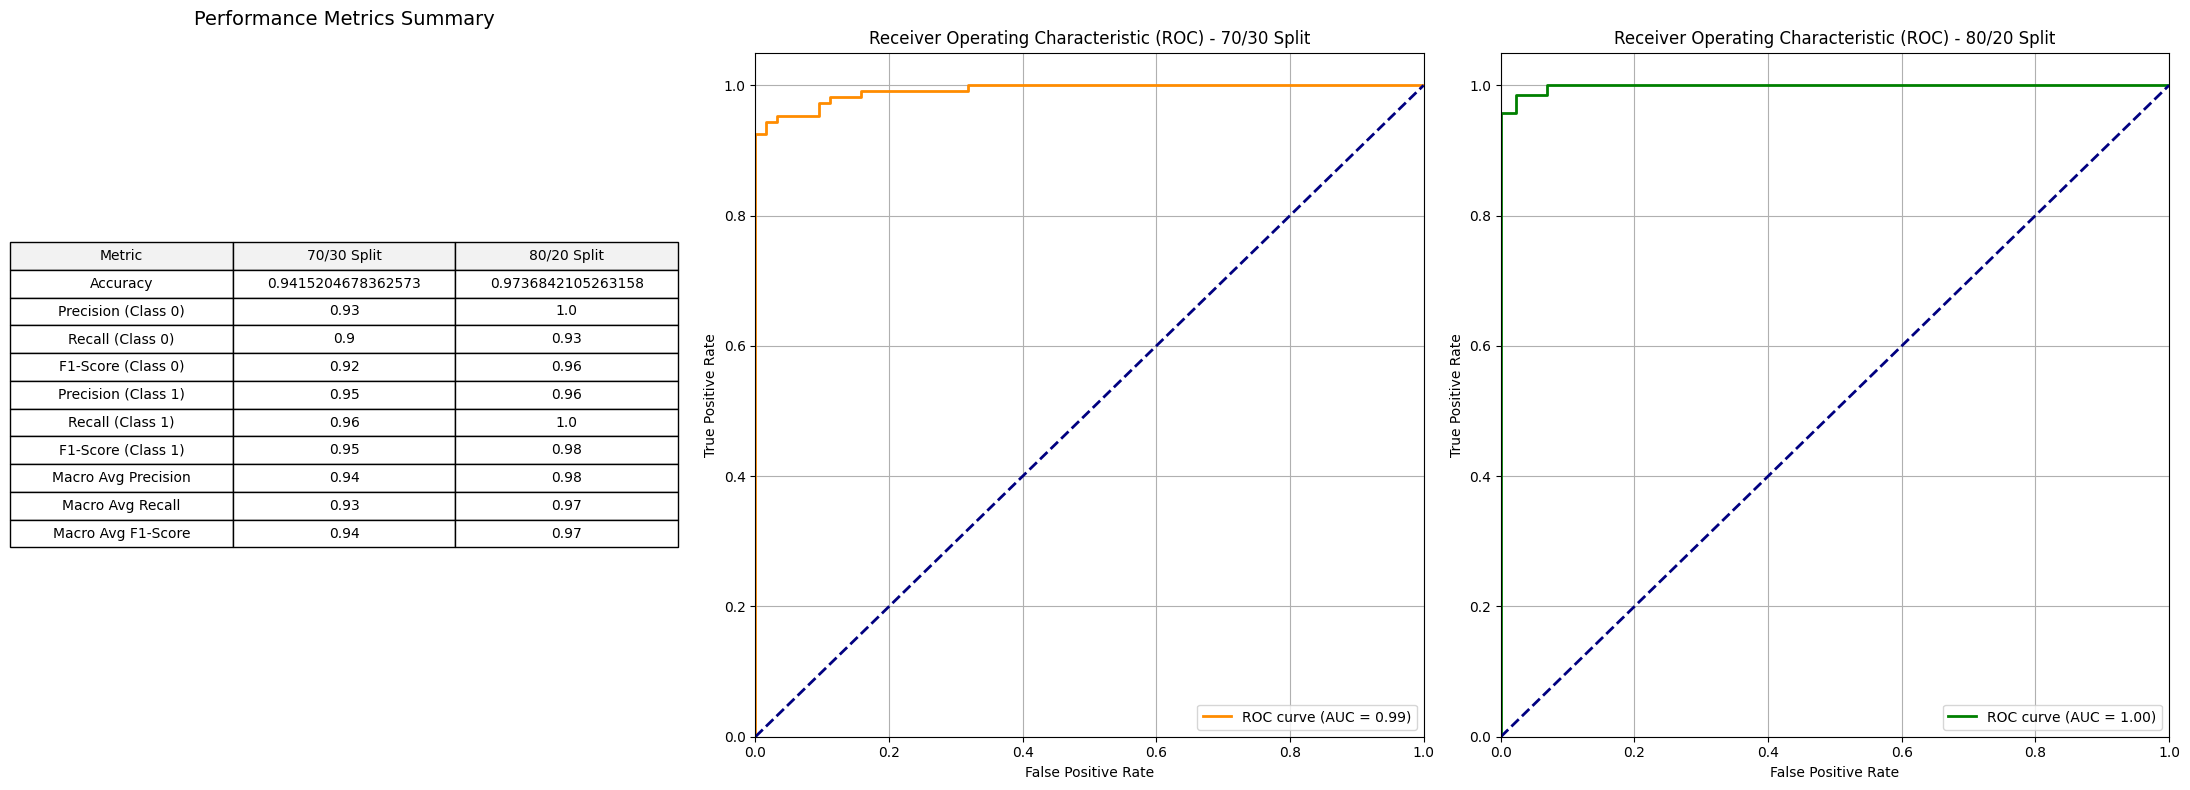

Combined performance metrics table and ROC curves generated.


In [6]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Ensure all necessary variables are available from previous executions
# metrics_df, fpr_70, tpr_70, roc_auc_70, fpr_80, tpr_80, roc_auc_80

fig = plt.figure(figsize=(22, 8)) # Adjust figure size for better layout
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1]) # Ratios for table, ROC 70/30, ROC 80/20

# --- Plot the Table (Left Panel) ---
ax0 = fig.add_subplot(gs[0])
ax0.axis('off') # Hide axes for the table
ax0.axis('tight') # Adjust limits to only show the table content

# Create the table
table = ax0.table(cellText=metrics_df.values,
                  colLabels=metrics_df.columns,
                  loc='center',
                  cellLoc='center',
                  colColours=['#f2f2f2']*len(metrics_df.columns)) # Light gray background for columns
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5) # Scale table rows for better readability
ax0.set_title('Performance Metrics Summary', fontsize=14, loc='center', pad=20)


# --- Plot ROC for 70/30 Split (Middle Panel) ---
ax1 = fig.add_subplot(gs[1])
ax1.plot(fpr_70, tpr_70, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_70:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC) - 70/30 Split')
ax1.legend(loc="lower right")
ax1.grid(True)

# --- Plot ROC for 80/20 Split (Right Panel) ---
ax2 = fig.add_subplot(gs[2])
ax2.plot(fpr_80, tpr_80, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_80:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver Operating Characteristic (ROC) - 80/20 Split')
ax2.legend(loc="lower right")
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Combined performance metrics table and ROC curves generated.")